# Import Libraries

In [71]:
# Import Basic Libraries..
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Import DL Libraries....
from tensorflow.keras.models import Sequential
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout, BatchNormalization,Activation
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import AdamW
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix

In [106]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [107]:
print('X_train :', X_train.shape)
print('X_test :', X_test.shape)
print('y_train :', y_train.shape)
print('y_test :', y_test.shape)

X_train : (50000, 32, 32, 3)
X_test : (10000, 32, 32, 3)
y_train : (50000, 1)
y_test : (10000, 1)


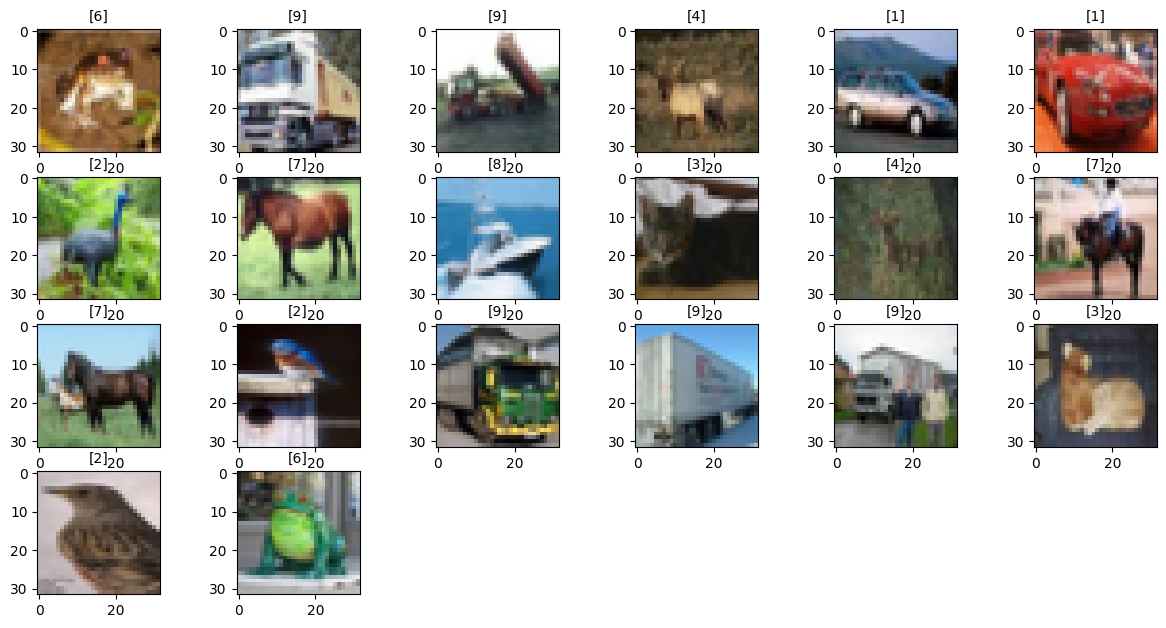

In [74]:
# Visualize 20 img.
plt.figure(figsize=(15, 15))

for i in range(20):
    # create subplot for each img
    plt.subplot(8,6,i+1)
    # Display the img
    plt.imshow(X_train[i])
    # set title
    plt.title(y_train[i], fontsize=10)

plt.show()

In [108]:
# Normalization the data
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Copying values
y_test_real = y_test.copy()
y_train_real = y_train.copy()

# One-Hot-Encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Implement CNN

In [76]:
model = Sequential()

# Layer 1
model.add(Conv2D(64, (3,3), padding="same", input_shape=(32,32,3)))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.25))

# Layer 2
model.add(Conv2D(64, (3,3), padding="same"))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(MaxPooling2D(2,2))

# Layer 3
model.add(Conv2D(128, (3,3), padding="same"))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(Dropout(0.25))

# Layer 4
model.add(Conv2D(128, (3,3), padding="same"))
model.add(BatchNormalization())
model.add(Activation("relu"))

# Layer 5
model.add(Conv2D(256, (3,3), padding="same"))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(MaxPooling2D(2,2))


model.add(Flatten())


# Fully Connected Layers
model.add(Dense(256))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(Dropout(0.5))

model.add(Dense(128))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(Dropout(0.5))

model.add(Dense(128))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(Dropout(0.5))

model.add(Dense(10, activation="softmax"))

In [77]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_28 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_36 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_37 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_38 (Activation)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_39 (Activation)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_40 (Activation)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,659,466 (6.33 MB)

 Trainable params: 1,657,162 (6.32 MB)

 Non-trainable params: 2,304 (9.00 KB)

In [79]:
# Auto Adjusting Learning Rate
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor= 0.5,
    patience= 3,
    min_lr = 1e-6,
    verbose = 0
)

# Update AdamW Optimizer
optimizer = AdamW(
    learning_rate = 1e-3,
    weight_decay = 1e-4
)

# Compiling the model
model.compile(
    optimizer = optimizer,
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

# For avoiding overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience= 20,
    restore_best_weights=True
)

# Training our model
history = model.fit(
    X_train,
    y_train,
    epochs = 100,
    batch_size = 128,
    verbose = 1,
    callbacks = [reduce_lr, early_stop],
    validation_data = (X_test, y_test)
)

Epoch 1/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.3391 - loss: 1.8398 - val_accuracy: 0.1662 - val_loss: 2.6528 - learning_rate: 0.0010
Epoch 2/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.5423 - loss: 1.2903 - val_accuracy: 0.4003 - val_loss: 2.0501 - learning_rate: 0.0010
Epoch 3/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.6305 - loss: 1.0750 - val_accuracy: 0.6332 - val_loss: 1.0547 - learning_rate: 0.0010
Epoch 4/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.6818 - loss: 0.9496 - val_accuracy: 0.6486 - val_loss: 1.0774 - learning_rate: 0.0010
Epoch 5/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.7146 - loss: 0.8602 - val_accuracy: 0.7230 - val_loss: 0.8421 - learning_rate: 0.0010
Epoch 6/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.7439 - loss: 0.7859 - val_accuracy: 0.6252 - val_loss: 1.1433 - learning_rate: 0.0010
Epoch 7/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.7670 - 

In [82]:
loss, acu = model.evaluate(X_test, y_test, verbose=0)

print('Accuracy:', acu)

Accuracy: 0.8450999855995178


# Visualizing Model Scores

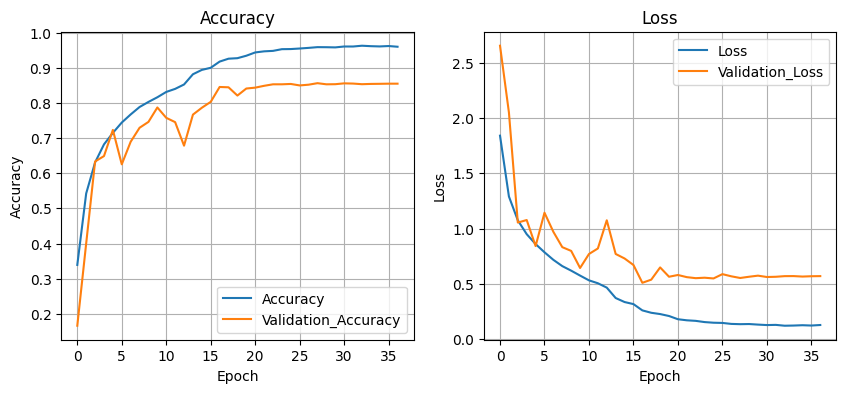

In [94]:
fig, ax = plt.subplots(1,2, figsize=(10,4))
# Accuracy
ax[0].plot(history.history['accuracy'], label='Accuracy')
ax[0].plot(history.history['val_accuracy'], label='Validation_Accuracy')
ax[0].set_title('Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')
ax[0].grid(True)
ax[0].legend()

# Loss
ax[1].plot(history.history['loss'], label='Loss')
ax[1].plot(history.history['val_loss'], label='Validation_Loss')
ax[1].set_title('Loss')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].grid(True)
ax[1].legend()

plt.show()

In [109]:
# Get Model Predictions
y_pred = model.predict(X_test)
# Convert Probabilities to final predict class
y_pred_classes = np.argmax(y_pred, axis=1)
# Reshape the label data(N,1)->(N)
y_true = y_test_real.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [110]:
# Visualize Pridected imgs
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print(classification_report(
    y_true,
    y_pred_classes,
    target_names = class_names
))

              precision    recall  f1-score   support

    airplane       0.87      0.83      0.85      1000
  automobile       0.96      0.92      0.94      1000
        bird       0.81      0.77      0.79      1000
         cat       0.67      0.73      0.70      1000
        deer       0.80      0.86      0.83      1000
         dog       0.78      0.74      0.76      1000
        frog       0.86      0.90      0.88      1000
       horse       0.93      0.84      0.89      1000
        ship       0.87      0.95      0.91      1000
       truck       0.92      0.91      0.91      1000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



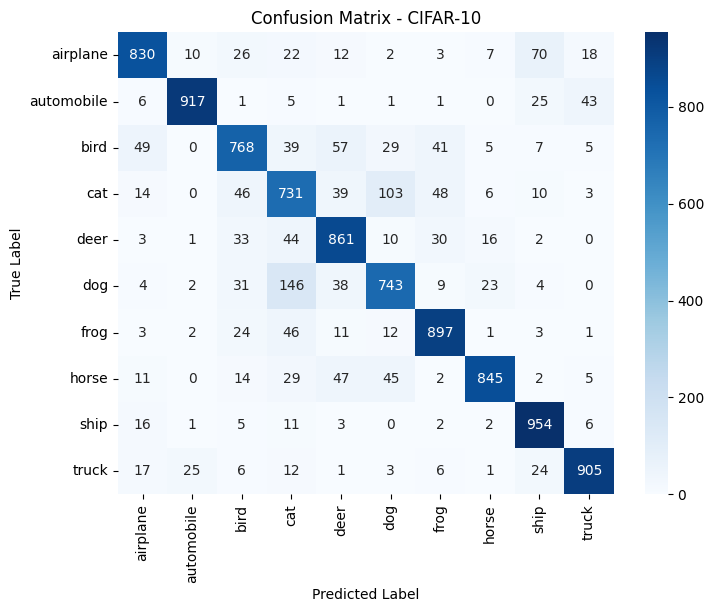

In [113]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(
    data = cm,
    annot = True,
    fmt = 'd',
    cmap = 'Blues',
    xticklabels = class_names,
    yticklabels = class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - CIFAR-10")
plt.show()

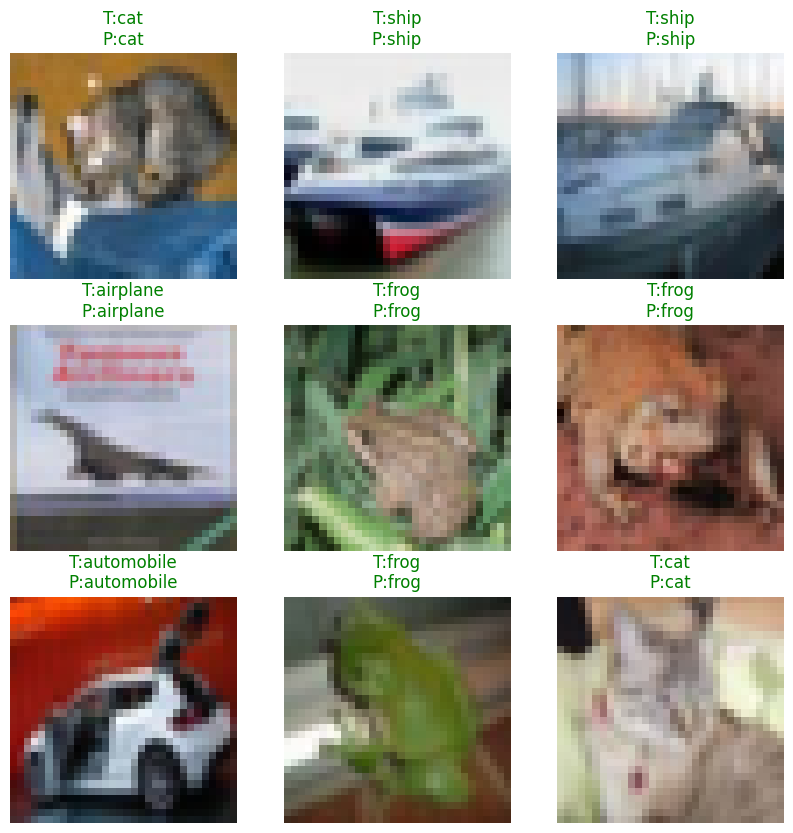

In [117]:
plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    
    plt.imshow(X_test[i])
    
    true_label = class_names[y_true[i]]
    pred_label = class_names[y_pred_classes[i]]
    
    color = "green" if y_true[i] == y_pred_classes[i] else "red"
    
    plt.title(f"T:{true_label}\nP:{pred_label}", color=color)
    plt.axis("off")

plt.show()

# Saving The Model

In [119]:
model.save('cifar_img_classifier.keras')